# Multi-Year Analysis of DSN Scintillation Events (2010–2014)

This notebook compares CIR and transient detections across multiple years of DSN tracking data.

---

## Purpose

To evaluate:

- consistency of the detection pipeline
- year-to-year variability in solar wind structure
- frequency and properties of transient disturbances

---

## Data Inputs

For each year, we load:

- daily metrics
- phase scintillation windows
- CIR region catalogue
- transient event catalogue

These are produced by Notebooks 1–3.

---

## Analysis Performed

1. Summary statistics per year:
   - number of CIRs
   - number of transient events
   - signal strength metrics

2. Distribution analysis:
   - CIR durations
   - transient durations

3. Time-series overview:
   - phase_ratio evolution
   - CIR regions
   - transient events

---

## Interpretation

This notebook provides a high-level view of how:

- solar wind conditions evolve over time
- DSN scintillation responds to heliospheric structure
- the detection method performs consistently across datasets

---

## Output

- Multi-year summary table
- Comparison plots
- Final figures suitable for reporting or publication

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

YEARS = ["2010", "2011","2012","2013","2014"]

OUTPUTS_ROOT = PROJECT_ROOT / "outputs"

save_file = True
debug = True

from src.plot_utils import plot_multi_year_summary, plot_multi_year_overview


In [2]:
all_daily = {}
all_windows = {}
all_cir = {}
all_events = {}

for year in YEARS:
    year_dir = OUTPUTS_ROOT / year

    daily_file = year_dir / f"daily_metrics_{year}.csv"
    windows_file = year_dir / f"phase_windows_detected_{year}.csv"
    cir_file = year_dir / f"cir_regions_{year}.csv"
    events_file = year_dir / f"transient_events_{year}.csv"

    # daily
    if daily_file.exists():
        daily_df = pd.read_csv(daily_file, parse_dates=["day"])
        all_daily[year] = daily_df
    else:
        print(f"Missing daily file for {year}: {daily_file}")

    # windows
    if windows_file.exists():
        windows_df = pd.read_csv(
            windows_file,
            parse_dates=["start", "end", "mid"]
        )
        all_windows[year] = windows_df
    else:
        print(f"Missing windows file for {year}: {windows_file}")

    # cir
    if cir_file.exists():
        cir_df = pd.read_csv(
            cir_file,
            parse_dates=["start", "end"]
        )
        all_cir[year] = cir_df
    else:
        print(f"Missing CIR file for {year}: {cir_file}")

    # transient events
    if events_file.exists():
        events_df = pd.read_csv(
            events_file,
            parse_dates=["start", "end"]
        )
        all_events[year] = events_df
    else:
        print(f"Missing transient file for {year}: {events_file}")
if debug == True:
    print("Loaded daily years:", list(all_daily.keys()))
    print("Loaded windows years:", list(all_windows.keys()))
    print("Loaded CIR years:", list(all_cir.keys()))
    print("Loaded event years:", list(all_events.keys()))

Loaded daily years: ['2010', '2011', '2012', '2013', '2014']
Loaded windows years: ['2010', '2011', '2012', '2013', '2014']
Loaded CIR years: ['2010', '2011', '2012', '2013', '2014']
Loaded event years: ['2010', '2011', '2012', '2013', '2014']


In [3]:
summary_rows = []

for year in YEARS:
    daily_df = all_daily.get(year)
    windows_df = all_windows.get(year)
    cir_df = all_cir.get(year)
    events_df = all_events.get(year)

    row = {
        "year": year,
        "n_daily_rows": len(daily_df) if daily_df is not None else np.nan,
        "n_windows": len(windows_df) if windows_df is not None else np.nan,
        "n_cir": len(cir_df) if cir_df is not None else np.nan,
        "n_transient": len(events_df) if events_df is not None else np.nan,
        "median_phase_rms": windows_df["phase_rms_rad"].median() if windows_df is not None else np.nan,
        "max_phase_rms": windows_df["phase_rms_rad"].max() if windows_df is not None else np.nan,
        "median_phase_ratio": windows_df["phase_ratio"].median() if (windows_df is not None and "phase_ratio" in windows_df.columns) else np.nan,
        "max_phase_ratio": windows_df["phase_ratio"].max() if (windows_df is not None and "phase_ratio" in windows_df.columns) else np.nan,
        "median_clean_signal": windows_df["clean_signal"].median() if (windows_df is not None and "clean_signal" in windows_df.columns) else np.nan,
        "max_clean_signal": windows_df["clean_signal"].max() if (windows_df is not None and "clean_signal" in windows_df.columns) else np.nan,
        "cir_total_duration_hr": cir_df["duration_hr"].sum() if (cir_df is not None and not cir_df.empty) else 0.0,
        "transient_total_duration_hr": events_df["duration_hr"].sum() if (events_df is not None and not events_df.empty) else 0.0,
    }

    summary_rows.append(row)
if debug:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

,year,n_daily_rows,n_windows,n_cir,n_transient,median_phase_rms,max_phase_rms,median_phase_ratio,max_phase_ratio,median_clean_signal,max_clean_signal,cir_total_duration_hr,transient_total_duration_hr
0,2010,336,14590,35,19,0.573515,63.824174,1.195138,116.376474,0.999173,129.278157,3613.833333,9.166667
1,2011,326,13528,35,25,0.929088,74.851036,1.178744,53.000896,1.001737,20.139194,3734.833333,32.833333
2,2012,323,15578,39,15,0.397292,76.419309,1.204544,150.316932,1.000956,41.008426,3797.166667,7.166667
3,2013,335,13289,35,11,0.908026,84.428370,1.160775,73.462994,1.000320,7.545557,3150.500000,3.833333
4,2014,111,4065,10,1,0.418971,22.227667,1.152603,50.426107,1.000412,20.721716,984.666667,0.500000


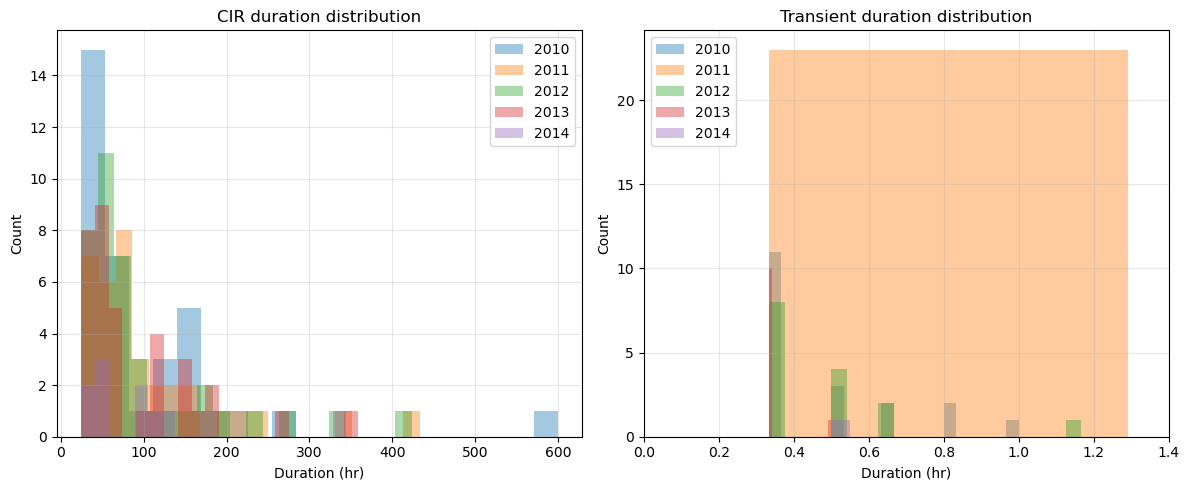

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CIR durations
for year in YEARS:
    cir_df = all_cir.get(year)
    if cir_df is not None and not cir_df.empty:
        axes[0].hist(
            cir_df["duration_hr"],
            bins=20,
            alpha=0.4,
            label=year
        )

axes[0].set_title("CIR duration distribution")
axes[0].set_xlabel("Duration (hr)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# transient durations
for year in YEARS:
    events_df = all_events.get(year)
    if events_df is not None and not events_df.empty:
        axes[1].hist(
            events_df["duration_hr"],
            bins=20,
            alpha=0.4,
            label=year
        )

axes[1].set_title("Transient duration distribution")
axes[1].set_xlabel("Duration (hr)")
axes[1].set_xlim(0,1.4)
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

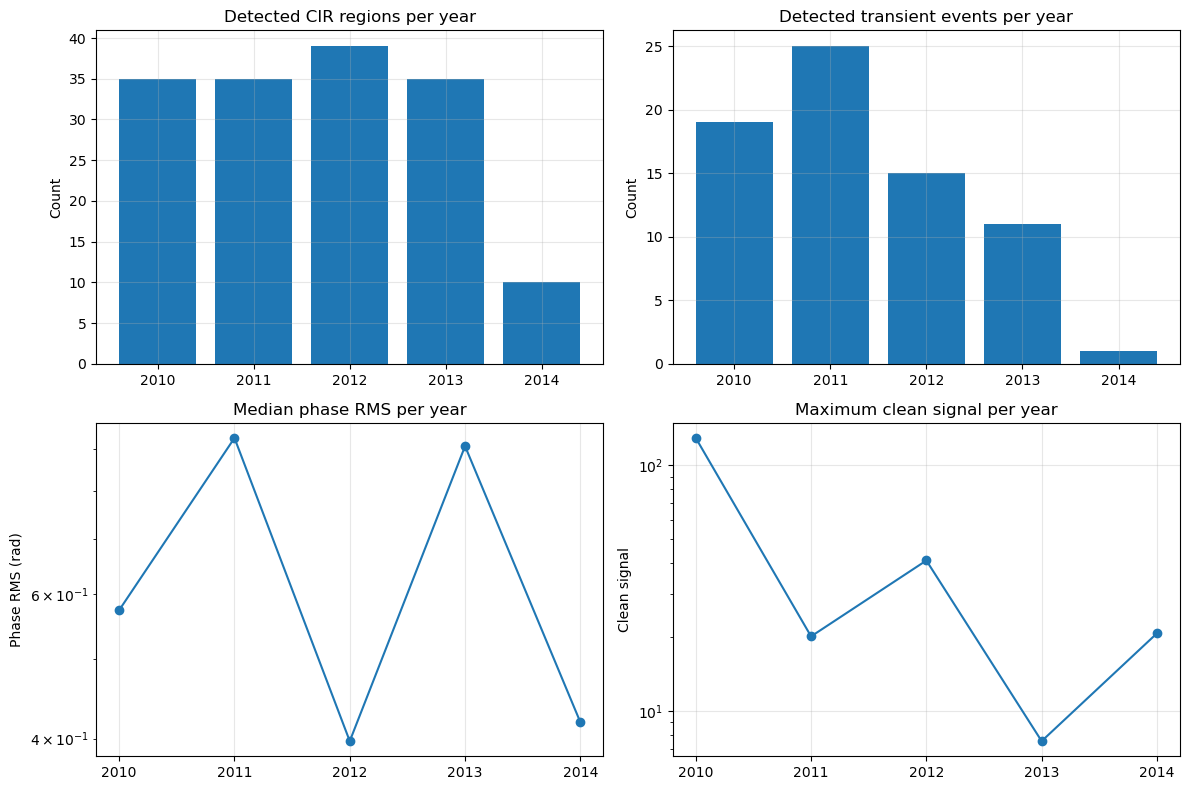

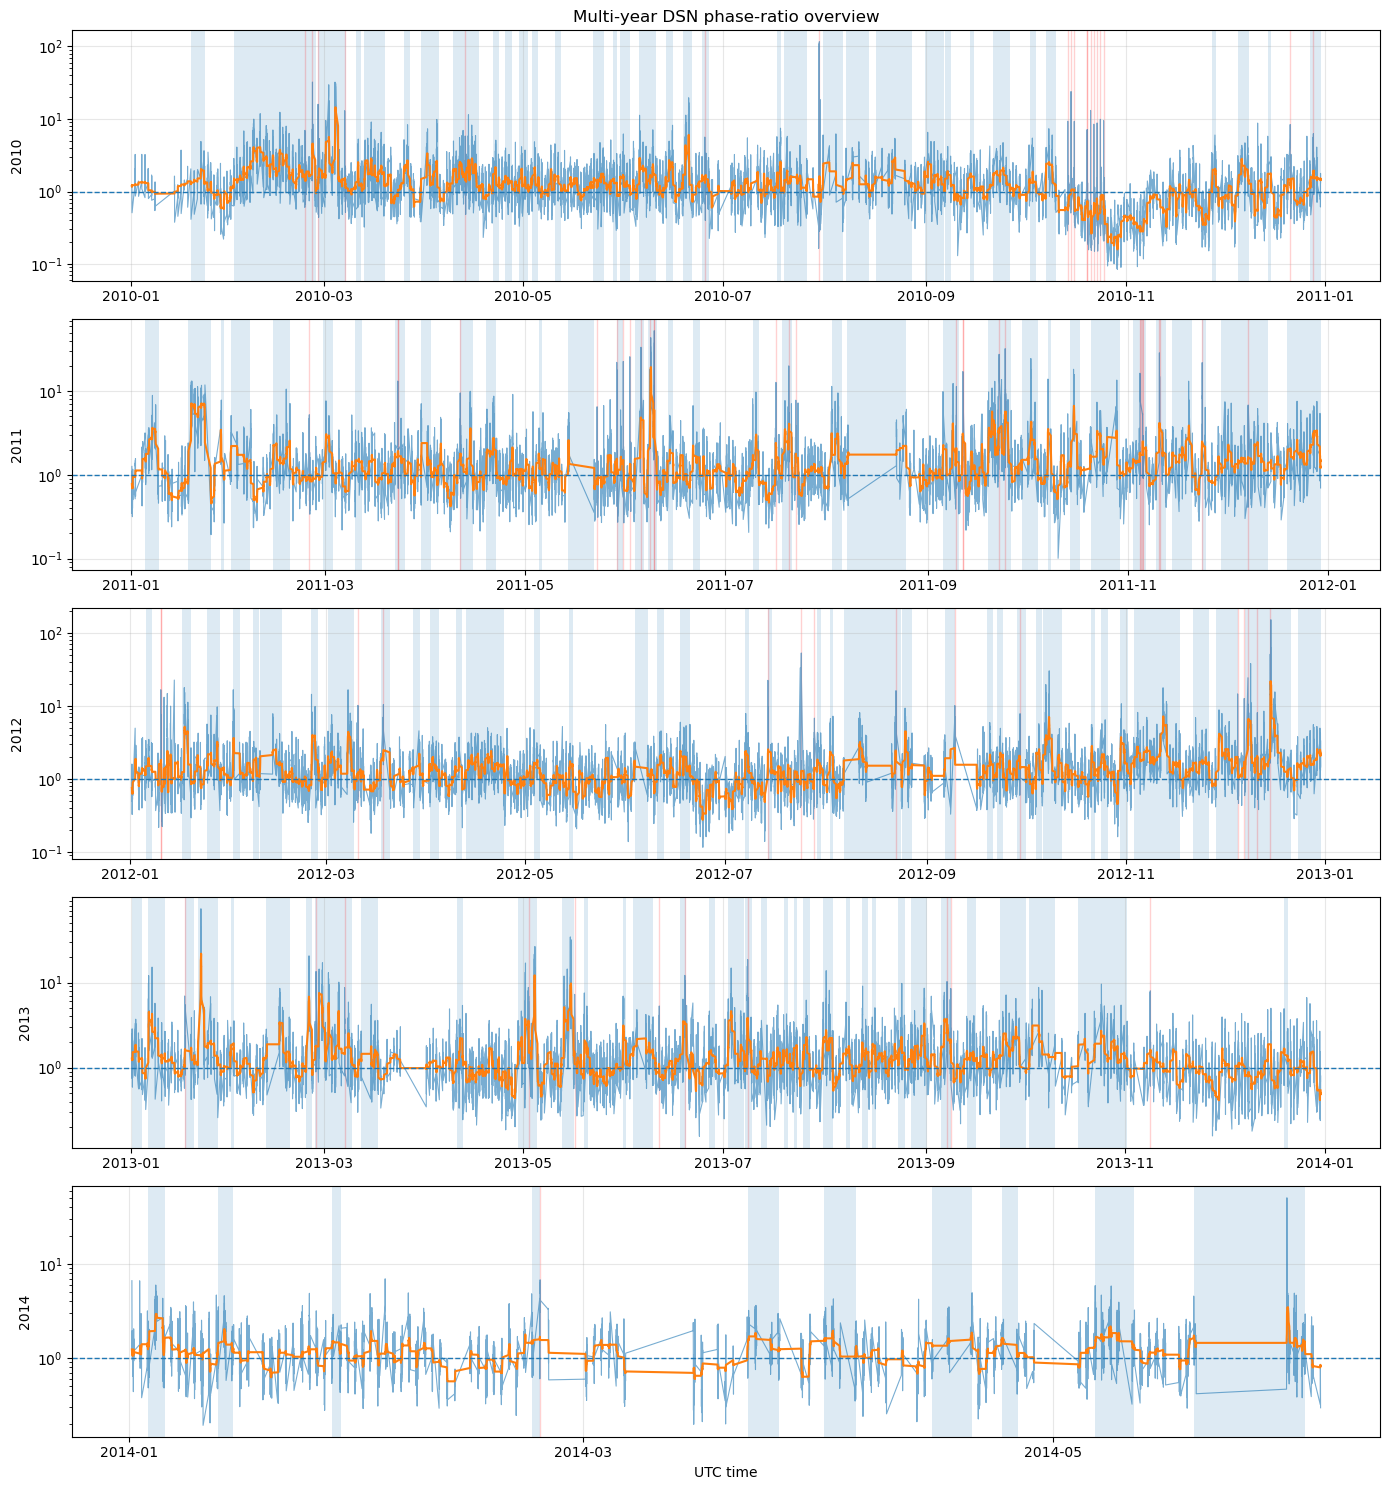

In [5]:
fig, axes = plot_multi_year_summary(summary_df)
plt.show()

fig, axes = plot_multi_year_overview(
    years=YEARS,
    all_windows=all_windows,
    all_cir=all_cir,
    all_events=all_events,
)
plt.show()

In [6]:
if save_file:
    summary_out = OUTPUTS_ROOT / "multi_year_summary.csv"
    summary_df.to_csv(summary_out, index=False)
    print("Saved:", summary_out)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/multi_year_summary.csv
